## How are in-demand skills trending for Data Analysts?

### Methodology

1. Aggregate skill counts monthly
2. Plot the monthly skill counts
3. Re-analyze based on percentage of total jobs
4. Plot the monthly skill demand

#### Original Exploration

[12_Exercise_Trending_Skills.ipynb](D:/Python_Data_Project/2_Advanced/12_Exercise_Trending_Skills.ipynb)

### Import Libraries & Data

In [3]:
# Importing Libraries
import ast
import pandas as pd
import seaborn as sns
from datasets import load_dataset
import matplotlib.pyplot as plt  

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [4]:
df_DA_IN = df[(df['job_title_short'] == 'Data Analyst') & (df['job_location'] == 'India')].copy()

In [5]:
df_DA_IN['job_posted_month_no'] = df['job_posted_date'].dt.month

In [6]:
df_DA_IN_explode =  df_DA_IN.explode('job_skills')

In [7]:
df_DA_IN_pivot = df_DA_IN_explode.pivot_table(index='job_posted_month_no', columns='job_skills', aggfunc='size', fill_value=0)

df_DA_IN_pivot.loc['Total'] = df_DA_IN_pivot.sum()

df_DA_IN_pivot = df_DA_IN_pivot[df_DA_IN_pivot.loc['Total'].sort_values(ascending=False).index]

df_DA_IN_pivot = df_DA_IN_pivot.drop('Total')

df_DA_IN_pivot

job_skills,sql,excel,python,tableau,power bi,r,sas,powerpoint,azure,aws,...,ionic,react.js,solidity,symphony,suse,vue.js,wire,workfront,wrike,yarn
job_posted_month_no,,,,,,,,,,,,,,,,,,,,,
1,64,53,43,36,24,12,22,13,10,8,...,0,0,0,0,0,0,0,0,0,0
2,57,42,38,29,17,19,16,8,8,10,...,0,0,0,1,0,0,0,0,0,0
3,53,34,32,33,17,20,16,7,7,3,...,0,0,0,0,1,0,0,0,0,0
4,50,35,39,22,25,11,8,8,11,4,...,0,1,0,0,0,0,0,0,0,0
5,80,62,46,41,28,20,16,18,13,7,...,0,0,0,0,0,0,0,0,0,0
6,96,66,72,63,38,32,26,18,20,17,...,0,0,0,0,0,0,0,1,0,0
7,124,96,74,65,56,26,36,20,18,16,...,0,0,0,0,0,0,0,0,0,0
8,112,64,79,57,51,33,38,14,20,27,...,0,0,0,0,0,0,0,0,0,1
9,87,71,64,50,39,27,16,12,6,12,...,0,0,0,0,0,0,0,0,0,0


In [8]:
DA_totals = df_DA_IN.groupby('job_posted_month_no').size()

In [9]:
df_DA_IN_percent = df_DA_IN_pivot.div(DA_totals/100, axis=0)

In [10]:
# changes month no to month name
df_DA_IN_percent = df_DA_IN_percent.reset_index()
df_DA_IN_percent['job_posted_month'] = df_DA_IN_percent['job_posted_month_no'].apply(lambda x: pd.to_datetime(x, format='%m').strftime('%b'))
df_DA_IN_percent = df_DA_IN_percent.set_index('job_posted_month')
df_DA_IN_percent = df_DA_IN_percent.drop(columns='job_posted_month_no')

df_DA_IN_percent

job_skills,sql,excel,python,tableau,power bi,r,sas,powerpoint,azure,aws,...,ionic,react.js,solidity,symphony,suse,vue.js,wire,workfront,wrike,yarn
job_posted_month,,,,,,,,,,,,,,,,,,,,,
Jan,43.835616,36.301370,29.452055,24.657534,16.438356,8.219178,15.068493,8.904110,6.849315,5.479452,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Feb,53.773585,39.622642,35.849057,27.358491,16.037736,17.924528,15.094340,7.547170,7.547170,9.433962,...,0.000000,0.000000,0.000000,0.943396,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Mar,61.627907,39.534884,37.209302,38.372093,19.767442,23.255814,18.604651,8.139535,8.139535,3.488372,...,0.000000,0.000000,0.000000,0.000000,1.162791,0.000000,0.000000,0.000000,0.000000,0.000000
Apr,43.103448,30.172414,33.620690,18.965517,21.551724,9.482759,6.896552,6.896552,9.482759,3.448276,...,0.000000,0.862069,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
May,54.054054,41.891892,31.081081,27.702703,18.918919,13.513514,10.810811,12.162162,8.783784,4.729730,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Jun,51.063830,35.106383,38.297872,33.510638,20.212766,17.021277,13.829787,9.574468,10.638298,9.042553,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.531915,0.000000,0.000000
Jul,51.028807,39.506173,30.452675,26.748971,23.045267,10.699588,14.814815,8.230453,7.407407,6.584362,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Aug,46.280992,26.446281,32.644628,23.553719,21.074380,13.636364,15.702479,5.785124,8.264463,11.157025,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.413223
Sep,45.312500,36.979167,33.333333,26.041667,20.312500,14.062500,8.333333,6.250000,3.125000,6.250000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


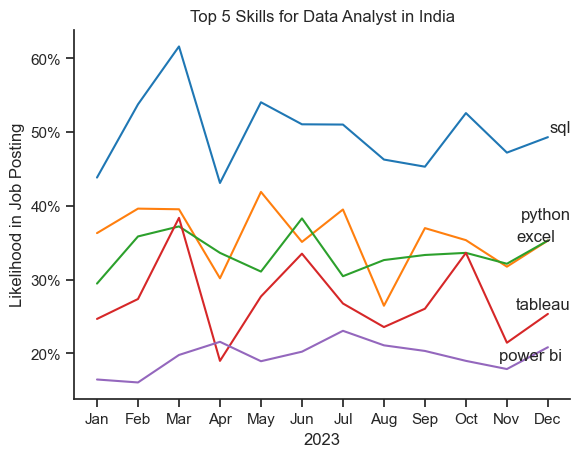

In [12]:
df_plot = df_DA_IN_percent.iloc[:, :5]

sns.lineplot(data=df_plot, dashes=False, palette='tab10')
sns.set_theme(style='ticks')
sns.despine()

plt.title('Top 5 Skills for Data Analyst in India')
plt.ylabel('Likelihood in Job Posting')
plt.xlabel('2023')
plt.legend().remove()

from matplotlib.ticker import PercentFormatter
ax = plt.gca()
ax.yaxis.set_major_formatter(PercentFormatter(decimals=0))

from adjustText import adjust_text

texts = []

for i in range(5):
    texts.append(plt.text(11.2, df_plot.iloc[-1, i], df_plot.columns[i]))
adjust_text(texts)

plt.show()